# Adversarial Stochastic Discount Factor — The Two-Step Framework's Exception

**Docker image**: `ml4t-gpu`

**Chapter 14: Latent Factors**

This notebook implements the adversarial-moment SDF of Chen, Pelger, and
Zhu (2024) *"Deep Learning in Asset Pricing"* and explains why the SDF
departs from the chapter's two-step framework. PCA, IPCA, RP-PCA, and CAE
all factorise prediction into Stage 1 (factor model) + Stage 2 (factor
premium forecaster) + Stage 3 (asset mapper). The SDF folds the per-asset
prediction directly into a paper-faithful **beta network** (CPZ 2024,
§"Beta Network") trained alongside the SDF — there is no separable Stage 2.

> **Why this is the exception (Figure 14.11)**: the three-phase adversarial
> training learns the conditional pricing kernel $M_t$. The "factor"
> $\hat F_{t+1} = \hat M_{t+1} - 1 = \sum_i \hat\omega_{t,i} R^e_{t+1,i}$
> is just one number per period — its
> one-step-ahead forecast is whatever the SDF training implicitly delivers.
> Per-asset predictions come from the beta network
> $\hat\beta_{t,i} = b_\psi(h_t, I_{t,i}) \approx \mathbb{E}_t[R^e_{t+1,i}\hat F_{t+1}]$,
> a separate supervised network trained on
> $y_{t,i} = R^e_{t+1,i}\hat F_{t+1}$. Ranking is on $\hat\beta_{t,i}$, not
> on the SDF weights $\hat\omega_{t,i}$.

## Attribution

> **Chen, Pelger, and Zhu (2024)** "Deep Learning in Asset Pricing".
> *Management Science*, 70(2), 714-750.
> [Paper](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=3350138)

Original TensorFlow reference:
https://github.com/YurongChen1998/Deep_Learning_in_Asset_Pricing

This implementation is a PyTorch educational port. The `case_studies/utils/latent_factors/sdf.py`
library mirrors the same training stack at production scale.

## What the framework cannot accommodate

| Component | PCA / IPCA / CAE / RP-PCA | SDF |
|-----------|---------------------------|-----|
| Stage 1 output | $F \in \mathbb{R}^{T \times K}$ + loading map | $\hat M_t \in \mathbb{R}^T$ via $\hat\omega_{t,i}$ |
| Stage 2 forecaster | Constant / AR(1) / EWMA / LightGBM / ... on $F$ | Implicit in conditional SDF training |
| Stage 3 mapper | $\hat\mu_{i,t} = \beta_{i,t}\cdot\hat\lambda_t$ | $\hat\beta_{t,i}$ from beta network (no separable mapper) |
| Per-asset prediction | $\hat\mu = \beta \cdot \hat\lambda$ | $\hat\beta_{t,i} = b_\psi(h_t, I_{t,i})$ |

**Why we still call it "Stage 1 + Stage 3"**: the SDF training step plays
the role of Stage 1 (it identifies the pricing kernel and the implied
factor $\hat F$); the beta network plays the role of a Stage-3-like asset
mapper (it projects characteristics + macro state into a per-asset signal).
But unlike PCA/IPCA/CAE, you **cannot replace the SDF's Stage 2
forecaster** without re-architecting the model — the conditional moment
objective bakes the forecast in.

## Adversarial training mechanics (paper-faithful)

**The pricing kernel $M_t$** prices all excess returns under no-arbitrage:
$\mathbb{E}[M_{t+1} R^e_{i,t+1}] = 0$ for every asset $i$ and every test
portfolio $g_{t,i}$. CPZ 2024 turn this into a saddle-point problem:

$$\min_\omega \max_g \big| \mathbb{E}[M_{t+1}\, R^e_{t+1}\, g_{t,i}] \big|^2$$

- **SDF network** $\omega_\theta(h_t, I_{t,i}) \to \hat\omega_{t,i}$,
  giving $\hat M_{t+1} = 1 + \sum_i \hat\omega_{t,i} R^e_{t+1,i}$
- **Moment network** $g_\phi(h_t', I_{t,i}) \to$ adversarial instruments
  that maximise pricing errors

**Three-phase training** (Figure 14.11 left half):
1. **Unconditional** ($\mathbb{E}[(M\cdot R\cdot 1)]^2 \to$ min): warm-start
   the SDF on the equal-weighted baseline.
2. **Instruments** ($-\mathbb{E}[(M\cdot R\cdot Z)]^2 \to$ min): freeze SDF;
   train moment network to *maximise* pricing errors.
3. **Conditional** ($\mathbb{E}[(M\cdot R\cdot Z)]^2 \to$ min): freeze
   instruments; SDF must price the adversarial portfolios.

Phases 2-3 alternate for several adversarial rounds. Hansen-Jagannathan
tells us the resulting SDF portfolio approximates the maximum-Sharpe
tangency portfolio in this asset universe.

**Predictive head** (Figure 14.11 right half):
4. After SDF training, freeze $\hat\omega$. Compute the realised tangency
   factor $\hat F_{t+1} = \sum_i \hat\omega_{t,i} R^e_{t+1,i}$ on the
   training window.
5. Train a small **beta network** $b_\psi(h_t, I_{t,i})$ to MSE-fit
   $y_{t,i} = R^e_{t+1,i}\,\hat F_{t+1}$. Under no-arbitrage,
   $b_\psi(h_t, I_{t,i}) \to \mathbb{E}_t[R^e_{t+1,i}\hat F_{t+1}] \propto
   \hat\beta_{t,i}$.
6. At decision date $t$, rank stocks by $\hat\beta_{t,i}$.

**Important**: do **not** rank stocks by $\hat\omega_{t,i}$. SDF weights
and expected-return signals are different objects (gpt-01 spec
§"Important implementation cautions"). The beta network is what turns SDF
training into a forecasting protocol comparable to the rest of the
chapter.

## Learning Objectives

- LO1: Recognise SDF training as the framework's exception — Stage 1 + 3
  without a swappable Stage 2
- LO2: Implement three-phase adversarial training in PyTorch
- LO3: Train a paper-faithful beta network as the per-asset predictive head
- LO4: Distinguish SDF *portfolio* diagnostics (Sharpe, pricing errors)
  from per-asset *prediction* quality (IC of $\hat\beta$ vs forward returns)

**Prerequisites**: CAE in framework
([`06_conditional_autoencoder`](06_conditional_autoencoder.ipynb)).
Requires US equities and FRED macro data.

**Book Reference**: Chapter 14, §14.7 (SDF, Beta Network); Figure 14.11.

## 1. Setup and Imports

In [1]:
"""Deep Learning Stochastic Discount Factor: Adversarial Moment Estimation."""

import warnings
from time import time
from typing import NamedTuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import torch
import torch.nn as nn
import torch.optim as optim
from ml4t.diagnostic.metrics import cross_sectional_ic, cross_sectional_ic_series

warnings.filterwarnings("ignore")

from data import load_macro, load_us_equities
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

# Figure output directory

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Universe-Size Scaling

SDF training has three nested loops: `NUM_ADVERSARIAL_ROUNDS` rounds, each
alternating an unconditional pretrain (`NUM_EPOCHS_UNCONDITIONAL`), a moment
network warm-up (`NUM_EPOCHS_INSTRUMENTS`), and a conditional joint phase
(`NUM_EPOCHS_CONDITIONAL`). Total wall-time scales as
$O(\text{rounds} \cdot \text{epochs} \cdot T \cdot \text{N\_STOCKS})$. The
default 200-stock × 3-round × 4 096-epoch joint phase runs ~5 minutes on the
local 3090. Halving `NUM_EPOCHS_CONDITIONAL` is the cheapest knob; halving
`N_STOCKS` to 100 cuts forward-pass cost roughly in half but reduces the
conditioning information the SDF can absorb. The β-network post-training
(`BETA_NET_EPOCHS`) is a separate ~30 s pass.

In [2]:
# Production defaults (Papermill overrides for CI testing)
N_STOCKS = 200
NUM_EPOCHS_UNCONDITIONAL = 1024
NUM_EPOCHS_INSTRUMENTS = 64
NUM_EPOCHS_CONDITIONAL = 4096
NUM_ADVERSARIAL_ROUNDS = 3
BETA_NET_EPOCHS = 256
BETA_NET_HIDDEN_DIM = 64
BETA_NET_STATE_DIM = 4
BETA_NET_LR = 1e-3
START_DATE = "1990-01-01"
END_DATE = "2018-12-31"
N_MACRO_COLS = 30
SEED = 42

In [3]:
set_global_seeds(SEED)
RANDOM_SEED = SEED
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True

# Network hyperparameters
DROPOUT = 0.05
STATE_DIM_SDF = 4  # LSTM hidden for SDF
STATE_DIM_MOMENT = 32  # LSTM hidden for moment network
N_INSTRUMENTS = 8  # Number of moment instruments
LEARNING_RATE = 1e-3

## 2. Data Loading

In [4]:
class DataSplit(NamedTuple):
    """Data for one train/valid/test split."""

    returns: torch.Tensor  # (T, N)
    asset_features: torch.Tensor  # (T, N, F_asset)
    macro_features: torch.Tensor  # (T, F_macro)
    mask: torch.Tensor  # (T, N) - True for valid observations
    n_obs_per_asset: torch.Tensor  # (N,) - count of valid obs per asset

### Load Raw Data

Load US equities (1962-2018, 4000+ stocks) and FRED macro indicators. We filter
to the target date range and select the most liquid stocks by average volume.

In [5]:
print("Loading US Equities and FRED macro data...")

equities_raw = load_us_equities(start_date=START_DATE, end_date=END_DATE)
print(f"  US Equities: {equities_raw.shape}")

macro_raw = load_macro()

print(f"  FRED macro: {macro_raw.shape}")

Loading US Equities and FRED macro data...


  US Equities: (14498930, 14)
  FRED macro: (9497, 26)


### Filter to Liquid Universe

Select the top stocks by average volume and compute cross-sectional features:
momentum, volatility, and mean-reversion signals.

In [6]:
equities = equities_raw.sort(["symbol", "timestamp"])

top_stocks = (
    equities.group_by("symbol")
    .agg(pl.col("volume").mean().alias("avg_volume"))
    .sort("avg_volume", descending=True)
    .head(N_STOCKS)["symbol"]
    .to_list()
)
equities = equities.filter(pl.col("symbol").is_in(top_stocks))

### Compute Asset Features

Engineer momentum, volatility, and mean-reversion signals from price data. These
characteristics serve as inputs to both the SDF and moment networks.

In [7]:
equities = equities.with_columns(
    [
        pl.col("adj_close").pct_change().over("symbol").alias("returns"),
        pl.col("adj_close").pct_change(5).over("symbol").alias("mom_5d"),
        pl.col("adj_close").pct_change(20).over("symbol").alias("mom_20d"),
        pl.col("adj_close").pct_change(60).over("symbol").alias("mom_60d"),
        pl.col("adj_close").pct_change().rolling_std(20).over("symbol").alias("vol_20d"),
        pl.col("adj_close").pct_change().rolling_std(60).over("symbol").alias("vol_60d"),
        (
            (pl.col("adj_close") - pl.col("adj_close").rolling_mean(20).over("symbol"))
            / pl.col("adj_close").rolling_std(20).over("symbol")
        ).alias("zscore_20d"),
        (pl.col("volume") / pl.col("volume").rolling_mean(20).over("symbol")).alias("vol_ratio"),
        pl.col("adj_close").log().alias("log_price"),
    ]
).drop_nulls()

feature_cols = [
    "mom_5d",
    "mom_20d",
    "mom_60d",
    "vol_20d",
    "vol_60d",
    "zscore_20d",
    "vol_ratio",
    "log_price",
]

### Build Panel Arrays

Pivot the long-format DataFrame into `(T, N, F)` tensors. Vectorized pivot is
much faster than row iteration for building the 3D panel.

In [8]:
tickers = top_stocks

returns_wide = (
    equities.select(["timestamp", "symbol", "returns"])
    .pivot(on="symbol", index="timestamp", values="returns")
    .sort("timestamp")
)
valid_dates = returns_wide["timestamp"].to_list()
ticker_cols = [c for c in returns_wide.columns if c != "timestamp"]

returns_arr = np.zeros((len(valid_dates), len(tickers)), dtype=np.float32)
for j, t in enumerate(tickers):
    if t in ticker_cols:
        returns_arr[:, j] = returns_wide[t].to_numpy().astype(np.float32)

features_arr = np.zeros((len(valid_dates), len(tickers), len(feature_cols)), dtype=np.float32)
for fi, feat in enumerate(feature_cols):
    feat_wide = (
        equities.select(["timestamp", "symbol", feat])
        .pivot(on="symbol", index="timestamp", values=feat)
        .sort("timestamp")
    )
    for j, t in enumerate(tickers):
        if t in feat_wide.columns:
            features_arr[:, j, fi] = feat_wide[t].to_numpy().astype(np.float32)

# Filter dates with sufficient coverage (80% of stocks)
min_stocks = int(N_STOCKS * 0.8)
valid_mask = np.sum(~np.isnan(returns_arr), axis=1) >= min_stocks
returns_arr = returns_arr[valid_mask]
features_arr = features_arr[valid_mask]
valid_dates = [d for d, v in zip(valid_dates, valid_mask, strict=False) if v]

mask_arr = ~np.isnan(returns_arr)
returns_arr = np.nan_to_num(returns_arr, 0.0)
features_arr = np.nan_to_num(features_arr, 0.0)

# Standardize asset features using train-window stats (60% chronological split).
# Raw log_price / vol_ratio / momentum are unbounded and can drive a fresh
# BetaNetwork forward pass to inf activations; z-scoring keeps activations in a
# bounded range and removes the need for a non-finite fallback in beta_loss.
_t_train_for_norm = int(features_arr.shape[0] * 0.6)
_feat_mean = features_arr[:_t_train_for_norm].mean(axis=(0, 1), keepdims=True)
_feat_std = features_arr[:_t_train_for_norm].std(axis=(0, 1), keepdims=True) + 1e-6
features_arr = (features_arr - _feat_mean) / _feat_std

### Process Macro Data

Align FRED macro indicators with equity trading dates using forward fill,
then normalize to zero mean and unit variance.

In [9]:
macro_dates = [d.date() if hasattr(d, "timestamp") else d for d in valid_dates]
macro_cols = [c for c in macro_raw.columns if c != "timestamp"][:N_MACRO_COLS]

macro_df = (
    macro_raw.filter(pl.col("timestamp").is_in(macro_dates))
    .sort("timestamp")
    # FRED series can carry NaN at dates where a release was missing — forward-fill
    # within each column so the downstream loop can't carry a NaN row forward and
    # poison the standardization that feeds the BetaNetwork.
    .with_columns([pl.col(c).forward_fill().backward_fill().fill_null(0.0) for c in macro_cols])
)
macro_arr = macro_df.select(macro_cols).to_numpy().astype(np.float32)

# Forward fill for missing macro dates
macro_full = np.zeros((len(valid_dates), len(macro_cols)), dtype=np.float32)
macro_date_to_row = {d: i for i, d in enumerate(macro_df["timestamp"].to_list())}

last_macro = np.zeros(len(macro_cols), dtype=np.float32)
for i, dt in enumerate(macro_dates):
    if dt in macro_date_to_row:
        last_macro = macro_arr[macro_date_to_row[dt]]
    macro_full[i] = last_macro

# Polars forward_fill leaves NaN floats untouched (it only fills nulls), so guard
# the array with nan_to_num before we standardize.
macro_full = np.nan_to_num(macro_full, nan=0.0, posinf=0.0, neginf=0.0)
macro_mean = macro_full.mean(axis=0)
macro_std = macro_full.std(axis=0) + 1e-8
macro_full = (macro_full - macro_mean) / macro_std

### Create Train/Valid/Test Splits

Split chronologically (60/20/20) and wrap each segment in a `DataSplit` NamedTuple
with GPU tensors ready for training.

In [10]:
T = len(valid_dates)
t_train = int(T * 0.6)
t_valid = int(T * 0.8)


def make_split(start_idx: int, end_idx: int, name: str) -> DataSplit:
    """Create a DataSplit for one time segment."""
    ret = returns_arr[start_idx:end_idx]
    feat = features_arr[start_idx:end_idx]
    mac = macro_full[start_idx:end_idx]
    msk = mask_arr[start_idx:end_idx]
    n_obs = msk.sum(axis=0).astype(np.float32)
    print(
        f"  {name}: T={ret.shape[0]}, N={ret.shape[1]}, "
        f"F_asset={feat.shape[2]}, F_macro={mac.shape[1]}"
    )
    return DataSplit(
        returns=torch.tensor(ret, dtype=torch.float32, device=device),
        asset_features=torch.tensor(feat, dtype=torch.float32, device=device),
        macro_features=torch.tensor(mac, dtype=torch.float32, device=device),
        mask=torch.tensor(msk, dtype=torch.bool, device=device),
        n_obs_per_asset=torch.tensor(n_obs, dtype=torch.float32, device=device),
    )


data = {
    "train": make_split(0, t_train, "train"),
    "valid": make_split(t_train, t_valid, "valid"),
    "test": make_split(t_valid, T, "test"),
}

  train: T=1633, N=200, F_asset=8, F_macro=25
  valid: T=544, N=200, F_asset=8, F_macro=25
  test: T=545, N=200, F_asset=8, F_macro=25


In [11]:
T_TRAIN, N_ASSETS = data["train"].returns.shape
N_ASSET_FEATURES = data["train"].asset_features.shape[2]
N_MACRO_FEATURES = data["train"].macro_features.shape[1]

print(
    f"\nDimensions: T={T_TRAIN}, N={N_ASSETS}, F_asset={N_ASSET_FEATURES}, F_macro={N_MACRO_FEATURES}"
)


Dimensions: T=1633, N=200, F_asset=8, F_macro=25


## 3. Model Architecture

### The Adversarial Framework

The model consists of two networks in adversarial competition:

**SDF Network**:
- Learns portfolio weights w that price assets correctly
- SDF = 1 + Σ(w_i × r_i) -- weighted combination of returns
- Goal: E[M × R × Z] = 0 for all test portfolios Z
- Success metric: Sharpe ratio of SDF portfolio (should hit HJ bound)

**Moment Network (Adversary)**:
- Learns instruments Z that identify mispriced assets
- Tries to find portfolios where SDF fails: E[M × R × Z] ≠ 0
- Acts as adversary, challenging the SDF to be more robust

### Why LSTM for Macro State?

Macro conditions (interest rates, volatility, credit spreads) evolve smoothly over time.
The LSTM captures this temporal state, conditioning both networks on the economic regime.
- During recessions: different factor exposures matter
- During expansions: different risk premia emerge

### The Hansen-Jagannathan Connection

The HJ bound says: Sharpe(M) ≥ Sharpe(any portfolio)

Our adversarial approach directly learns M to maximize this Sharpe ratio, subject to pricing all assets.
The final SDF portfolio should approach the theoretical maximum Sharpe ratio.

### Dual-network architecture at a glance

Both networks share a macro-state LSTM and read the same asset features
$x_{i,t}$; they differ only in their output head and the sign of the loss.

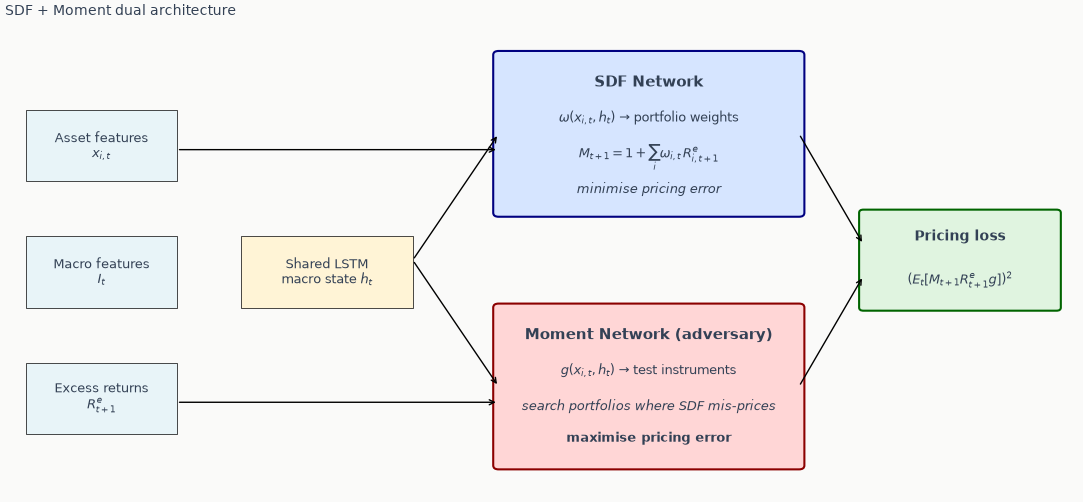

In [12]:
from matplotlib.patches import FancyBboxPatch, Rectangle  # noqa: E402

fig, ax = plt.subplots(figsize=(11, 5.2))
ax.set_xlim(0, 100)
ax.set_ylim(0, 60)
ax.axis("off")

ax.add_patch(Rectangle((2, 40), 14, 9, facecolor="#E8F4F8", edgecolor="black"))
ax.text(9, 44.5, "Asset features\n$x_{i,t}$", ha="center", va="center", fontsize=9)
ax.add_patch(Rectangle((2, 24), 14, 9, facecolor="#E8F4F8", edgecolor="black"))
ax.text(9, 28.5, "Macro features\n$I_t$", ha="center", va="center", fontsize=9)
ax.add_patch(Rectangle((2, 8), 14, 9, facecolor="#E8F4F8", edgecolor="black"))
ax.text(9, 12.5, "Excess returns\n$R^e_{t+1}$", ha="center", va="center", fontsize=9)

ax.add_patch(Rectangle((22, 24), 16, 9, facecolor="#FFF4D6", edgecolor="black"))
ax.text(30, 28.5, "Shared LSTM\nmacro state $h_t$", ha="center", va="center", fontsize=9)

ax.add_patch(
    FancyBboxPatch(
        (46, 36),
        28,
        20,
        boxstyle="round,pad=0.5",
        facecolor="#D6E5FF",
        edgecolor="navy",
        lw=1.5,
    )
)
ax.text(60, 52, "SDF Network", ha="center", fontweight="bold", fontsize=11)
ax.text(60, 47.5, r"$\omega(x_{i,t}, h_t)$ → portfolio weights", ha="center", fontsize=9)
ax.text(60, 43, r"$M_{t+1} = 1 + \sum_i \omega_{i,t}\,R^e_{i,t+1}$", ha="center", fontsize=9)
ax.text(60, 38.5, "minimise pricing error", ha="center", fontsize=9, style="italic")

ax.add_patch(
    FancyBboxPatch(
        (46, 4),
        28,
        20,
        boxstyle="round,pad=0.5",
        facecolor="#FFD6D6",
        edgecolor="darkred",
        lw=1.5,
    )
)
ax.text(60, 20, "Moment Network (adversary)", ha="center", fontweight="bold", fontsize=11)
ax.text(60, 15.5, r"$g(x_{i,t}, h_t)$ → test instruments", ha="center", fontsize=9)
ax.text(60, 11, "search portfolios where SDF mis-prices", ha="center", fontsize=9, style="italic")
ax.text(60, 7, "maximise pricing error", ha="center", fontsize=9, fontweight="bold")

ax.add_patch(
    FancyBboxPatch(
        (80, 24),
        18,
        12,
        boxstyle="round,pad=0.4",
        facecolor="#E0F4E0",
        edgecolor="darkgreen",
        lw=1.5,
    )
)
ax.text(89, 32.5, "Pricing loss", ha="center", fontweight="bold", fontsize=10)
ax.text(89, 27, r"$(E_t[M_{t+1} R^e_{t+1} g])^2$", ha="center", fontsize=9)

arrow = dict(arrowstyle="->", lw=1, color="black")
ax.annotate("", xy=(46, 46), xytext=(38, 30), arrowprops=arrow)
ax.annotate("", xy=(46, 14), xytext=(38, 30), arrowprops=arrow)
ax.annotate("", xy=(46, 44), xytext=(16, 44), arrowprops=arrow)
ax.annotate("", xy=(46, 12), xytext=(16, 12), arrowprops=arrow)
ax.annotate("", xy=(80, 32), xytext=(74, 46), arrowprops=arrow)
ax.annotate("", xy=(80, 28), xytext=(74, 14), arrowprops=arrow)

ax.set_title("SDF + Moment dual architecture")
fig.tight_layout()
fig.show()

### SDF Network

> **Import shortcut**: These classes are also available as
> `from case_studies.config.sdf.sdf import SDFNetwork, MomentNetwork` for use outside
> this notebook. The inline definition below is shown for pedagogical exposition.

The SDF network takes asset characteristics and macro state as input, and produces
portfolio weights. The SDF is constructed as $M_t = 1 + \sum_i w_i r_i$.

**Architecture detail**:
- `__init__`: Creates a MacroLSTM (`n_macro_features` $\to$ `state_dim`) that
  compresses the macro time series into a regime embedding, plus a 2-layer FFN
  (`n_asset_features + state_dim` $\to$ 1) that maps each asset's characteristics
  concatenated with the macro state to a scalar portfolio weight.
- `forward`: Runs the macro sequence through the LSTM, tiles the state across
  assets, masks to valid observations, and returns per-observation weights plus
  the LSTM hidden state for rolling evaluation.

In [13]:
class SDFNetwork(nn.Module):
    """SDF Network: asset characteristics + macro state -> portfolio weights."""

    def __init__(
        self,
        n_asset_features: int,
        n_macro_features: int,
        state_dim: int = 4,
        hidden_dim: int = 64,
        dropout: float = 0.05,
    ):
        super().__init__()
        self.state_dim = state_dim

        # MacroLSTM: extract economic regime state from macro indicators
        self.lstm = nn.LSTM(
            input_size=n_macro_features,
            hidden_size=state_dim,
            batch_first=True,
            dropout=dropout,
        )

        # FFN: asset features + macro state → weight
        self.ffn = nn.Sequential(
            nn.Linear(n_asset_features + state_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(
        self,
        asset_features: torch.Tensor,  # (T, N, F_asset)
        macro_features: torch.Tensor,  # (T, F_macro)
        mask: torch.Tensor,  # (T, N)
        h0: torch.Tensor | None = None,  # (1, 1, state_dim)
        c0: torch.Tensor | None = None,  # (1, 1, state_dim)
    ) -> tuple[torch.Tensor, tuple[torch.Tensor, torch.Tensor]]:
        """Forward pass: returns (weights, (h_n, c_n))."""
        T, N, F = asset_features.shape

        if h0 is None:
            h0 = torch.zeros(1, 1, self.state_dim, device=asset_features.device)
            c0 = torch.zeros(1, 1, self.state_dim, device=asset_features.device)

        # MacroLSTM: (1, T, F_macro) → (1, T, state_dim)
        macro_seq = macro_features.unsqueeze(0)
        macro_states, (h_n, c_n) = self.lstm(macro_seq, (h0, c0))
        macro_states = macro_states.squeeze(0)  # (T, state_dim)

        # Tile macro state for each asset, mask to valid observations
        macro_tiled = macro_states.unsqueeze(1).expand(-1, N, -1)
        asset_flat = asset_features[mask]  # (n_valid, F_asset)
        macro_flat = macro_tiled[mask]  # (n_valid, state_dim)

        # FFN produces one weight per valid observation
        ffn_input = torch.cat([asset_flat, macro_flat], dim=1)
        weights = self.ffn(ffn_input).squeeze(-1)  # (n_valid,)

        return weights, (h_n, c_n)

### Moment Network (Adversary)

The moment network learns instrument portfolios that expose SDF pricing failures.
It acts as the adversary: finding test assets where $E[M \cdot R \cdot Z] \neq 0$.

**Architecture detail**:
- `__init__`: Same MacroLSTM structure as the SDF network (but with larger
  `state_dim=32` for richer adversarial exploration), plus a single-layer FFN
  with tanh activation producing `n_instruments` outputs per asset-time pair.
- `forward`: Processes macro features through the LSTM, tiles the state across
  assets, and outputs instruments shaped `(n_instruments, T, N)`. Unlike the
  SDF network, no masking is applied here — instruments are defined for all
  asset-time pairs (masking happens in the loss function).

In [14]:
class MomentNetwork(nn.Module):
    """Moment Network: asset characteristics + macro state -> adversarial instruments."""

    def __init__(
        self,
        n_asset_features: int,
        n_macro_features: int,
        n_instruments: int = 8,
        state_dim: int = 32,
        dropout: float = 0.05,
    ):
        super().__init__()
        self.state_dim = state_dim
        self.n_instruments = n_instruments

        # MacroLSTM: extract economic regime state from macro indicators
        self.lstm = nn.LSTM(
            input_size=n_macro_features,
            hidden_size=state_dim,
            batch_first=True,
            dropout=dropout,
        )

        # FFN: asset features + macro state → instruments (tanh bounds to [-1, 1])
        self.ffn = nn.Sequential(
            nn.Linear(n_asset_features + state_dim, n_instruments),
            nn.Tanh(),
        )

    def forward(
        self,
        asset_features: torch.Tensor,  # (T, N, F_asset)
        macro_features: torch.Tensor,  # (T, F_macro)
        h0: torch.Tensor | None = None,
        c0: torch.Tensor | None = None,
    ) -> tuple[torch.Tensor, tuple[torch.Tensor, torch.Tensor]]:
        """Forward pass: returns (instruments, (h_n, c_n))."""
        T, N, F = asset_features.shape

        if h0 is None:
            h0 = torch.zeros(1, 1, self.state_dim, device=asset_features.device)
            c0 = torch.zeros(1, 1, self.state_dim, device=asset_features.device)

        # MacroLSTM: (1, T, F_macro) → (1, T, state_dim)
        macro_seq = macro_features.unsqueeze(0)
        macro_states, (h_n, c_n) = self.lstm(macro_seq, (h0, c0))
        macro_states = macro_states.squeeze(0)  # (T, state_dim)

        # Tile, concatenate, produce instruments
        macro_tiled = macro_states.unsqueeze(1).expand(-1, N, -1)
        ffn_input = torch.cat([asset_features, macro_tiled], dim=2)
        instruments = self.ffn(ffn_input)  # (T, N, n_instruments)

        # Transpose to (n_instruments, T, N) for loss computation
        instruments = instruments.permute(2, 0, 1)

        return instruments, (h_n, c_n)

## 4. SDF Construction and Loss Functions

### Segment IDs for Panel Aggregation

The masked panel `(T, N)` is flattened to valid observations only. Segment IDs
map each valid observation back to its time step, enabling `scatter_add` aggregation.

In [15]:
def get_segment_ids(mask: torch.Tensor) -> torch.Tensor:
    """Create segment IDs mapping valid observations to time steps."""
    T, N = mask.shape
    time_ids = torch.arange(T, device=mask.device).unsqueeze(1).expand(-1, N)
    return time_ids[mask]

### SDF Construction

The SDF is constructed as $M_t = 1 + \sum_i w_{i,t} r_{i,t}$, where weights come from
the SDF network. The `scatter_add` operation sums weighted returns within each time
step, producing one SDF value per period.

In [16]:
def construct_sdf(weights: torch.Tensor, returns: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    """Construct SDF from weights and returns: SDF_t = 1 + sum_i(w_i * r_i)."""
    T, N = returns.shape
    returns_flat = returns[mask]  # (n_valid,)
    segment_ids = get_segment_ids(mask)

    # Sum weighted returns by time step
    weighted_returns = weights * returns_flat
    sdf_values = torch.zeros(T, device=weights.device)
    sdf_values.scatter_add_(0, segment_ids, weighted_returns)

    return 1 + sdf_values

### Unconditional Loss

Phase 1 uses constant instruments ($Z = 1$), equivalent to testing whether the SDF
prices the equal-weighted market portfolio: $E[M \cdot R \cdot 1]^2 \to 0$.

In [17]:
def unconditional_loss(
    weights: torch.Tensor,
    returns: torch.Tensor,
    mask: torch.Tensor,
    n_obs_per_asset: torch.Tensor,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Unconditional pricing loss: E[M * R * 1]².

    Uses constant instrument (scalar 1).

    Args:
        weights: (n_valid,)
        returns: (T, N)
        mask: (T, N)
        n_obs_per_asset: (N,)

    Returns:
        loss: scalar MSE
        sdf: (T,)
    """
    T, N = returns.shape
    mask_float = mask.float()

    sdf = construct_sdf(weights, returns, mask)  # (T,)
    sdf_expanded = sdf.unsqueeze(1)  # (T, 1)

    # Constant instruments = 1
    instruments = torch.ones(1, T, N, device=weights.device)

    # Sample moments: r * M * Z for each (t, n)
    sample_moments = returns * mask_float * sdf_expanded * instruments  # (1, T, N)

    # Average over time, weighted by n_obs
    weighted_moments = sample_moments.sum(dim=1) / n_obs_per_asset.clamp(min=1)  # (1, N)

    # Normalize by max obs for stable loss
    n_obs_norm = n_obs_per_asset / n_obs_per_asset.max()

    # MSE loss
    loss = (weighted_moments.pow(2) * n_obs_norm).mean()

    return loss, sdf

### Conditional Loss

Phases 2-3 use learned instruments from the moment network. The adversary maximizes
$E[M \cdot R \cdot Z]^2$ to find hard test portfolios; the SDF minimizes it to price them.

In [18]:
def conditional_loss(
    weights: torch.Tensor,
    instruments: torch.Tensor,
    returns: torch.Tensor,
    mask: torch.Tensor,
    n_obs_per_asset: torch.Tensor,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Conditional pricing loss: E[M * R * Z]².

    Uses learned instruments from moment network.

    Args:
        weights: (n_valid,)
        instruments: (n_instruments, T, N)
        returns: (T, N)
        mask: (T, N)
        n_obs_per_asset: (N,)

    Returns:
        loss: scalar MSE
        sdf: (T,)
    """
    T, N = returns.shape
    n_instruments = instruments.shape[0]
    mask_float = mask.float()

    sdf = construct_sdf(weights, returns, mask)  # (T,)
    sdf_expanded = sdf.unsqueeze(1)  # (T, 1)

    # Sample moments: r * M * Z for each instrument
    sample_moments = returns * mask_float * sdf_expanded * instruments  # (n_instr, T, N)

    # Average over time, weighted by n_obs
    weighted_moments = sample_moments.sum(dim=1) / n_obs_per_asset.clamp(min=1)  # (n_instr, N)

    # Normalize by max obs
    n_obs_norm = n_obs_per_asset / n_obs_per_asset.max()

    # Tile for all instruments
    n_obs_tiled = n_obs_norm.unsqueeze(0).expand(n_instruments, -1)

    # MSE loss
    loss = (weighted_moments.pow(2) * n_obs_tiled).mean()

    return loss, sdf

### HJ-Bound Sharpe (daily) of the SDF Portfolio

The SDF portfolio return is $M_t - 1 = \sum_i \omega_{i,t} R^e_{i,t}$ (the
SDF-implied tangency portfolio's realised excess return). Its **daily** Sharpe
ratio $\bar r / s_r$ (no $\sqrt{252}$ here — this function returns the *daily*
value; an annualised companion is reported separately below) should approach
the **Hansen-Jagannathan bound**:

$$\frac{|E[R^e]|}{\sigma(R^e)} \le \frac{\sigma(M)}{E[M]}$$

the upper bound on the Sharpe ratio of any excess-return portfolio in this
asset universe. Hitting the bound means the SDF correctly prices every asset
in the panel; falling short means there are unpriced excess-return directions
the SDF has not absorbed.

In [19]:
def compute_sharpe(sdf: torch.Tensor) -> torch.Tensor:
    """Daily Sharpe ratio of the SDF portfolio (M - 1); compare against HJ bound."""
    portfolio_return = sdf - 1
    sharpe = portfolio_return.mean() / portfolio_return.std().clamp(min=1e-8)
    return sharpe

### Evaluation Helper

Shared across all three training phases: rolls LSTM state through train/valid/test
splits and computes loss + Sharpe for each.

In [20]:
def evaluate_splits(loss_fn, use_instruments: bool = False) -> dict:
    """Evaluate SDF (and optionally moment network) across all splits."""
    metrics = {}
    h_sdf, c_sdf = None, None
    h_mom, c_mom = None, None

    for split in ["train", "valid", "test"]:
        with torch.no_grad():
            w, (h_sdf, c_sdf) = sdf_net(
                data[split].asset_features,
                data[split].macro_features,
                data[split].mask,
                h_sdf,
                c_sdf,
            )
            if use_instruments:
                z, (h_mom, c_mom) = moment_net(
                    data[split].asset_features,
                    data[split].macro_features,
                    h_mom,
                    c_mom,
                )
                l, s = loss_fn(
                    w, z, data[split].returns, data[split].mask, data[split].n_obs_per_asset
                )
            else:
                l, s = loss_fn(
                    w, data[split].returns, data[split].mask, data[split].n_obs_per_asset
                )
            metrics[f"loss_{split}"] = l.item()
            metrics[f"sharpe_{split}"] = compute_sharpe(s).item()

    return metrics

## 5. Three-Phase Adversarial Training

### The Training Dance (Critical to Understand)

Unlike standard supervised learning, adversarial training alternates between two competing objectives:

**Phase 1: Unconditional (Warmup)**
- Use constant instrument Z = 1 (just market portfolio)
- Train SDF to minimize: E[(M x R x 1)]²
- Gets SDF to a reasonable starting point

**Phase 2: Instrument Training (Adversarial)**
- FREEZE the SDF network
- Train Moment Network to MAXIMIZE: E[(M x R x Z)]²
- The Moment Network is actively trying to break the SDF!
- It finds test portfolios where SDF pricing fails

**Phase 3: Conditional Training**
- FREEZE the Moment Network
- Train SDF to MINIMIZE: E[(M x R x Z)]²
- SDF must now price the adversarial portfolios correctly

**Repeat phases 2-3** for multiple adversarial rounds. Each round:
- Moment Network finds new weaknesses in SDF
- SDF adapts to price those portfolios correctly
- Eventually converges to robust SDF that prices everything

### Training schedule (visual)

Each adversarial round runs the three phases in sequence: SDF warmup,
adversary discovery, SDF refinement. The whole sequence repeats
`NUM_ADVERSARIAL_ROUNDS` times.

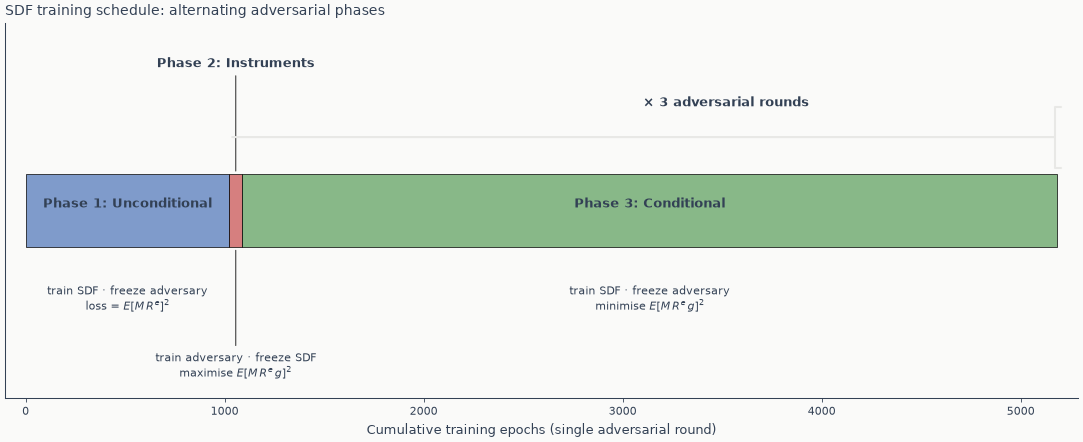

In [21]:
fig, ax = plt.subplots(figsize=(11, 4.6))
phases = [
    (
        "Phase 1: Unconditional",
        "train SDF · freeze adversary\nloss = $E[M\\,R^e]^2$",
        0,
        NUM_EPOCHS_UNCONDITIONAL,
        "#7F9BCB",
    ),
    (
        "Phase 2: Instruments",
        "train adversary · freeze SDF\nmaximise $E[M\\,R^e\\,g]^2$",
        NUM_EPOCHS_UNCONDITIONAL,
        NUM_EPOCHS_UNCONDITIONAL + NUM_EPOCHS_INSTRUMENTS,
        "#D67F7F",
    ),
    (
        "Phase 3: Conditional",
        "train SDF · freeze adversary\nminimise $E[M\\,R^e\\,g]^2$",
        NUM_EPOCHS_UNCONDITIONAL + NUM_EPOCHS_INSTRUMENTS,
        NUM_EPOCHS_UNCONDITIONAL + NUM_EPOCHS_INSTRUMENTS + NUM_EPOCHS_CONDITIONAL,
        "#88B888",
    ),
]
total_epochs = phases[-1][3]
# Phase widths span 3 orders of magnitude (Phase 1: 1000, Phase 2: ~100, Phase 3: 4000),
# so center-anchored labels collide on the narrow phase. Lift labels for narrow phases
# above and below the bar with leader lines.
narrow_threshold = 0.10 * total_epochs
for label, sub, x0, x1, color in phases:
    ax.barh(0, x1 - x0, left=x0, height=0.55, color=color, edgecolor="black")
    mid = (x0 + x1) / 2
    if (x1 - x0) < narrow_threshold:
        ax.annotate(
            label,
            xy=(mid, 0.275),
            xytext=(mid, 1.05),
            ha="center",
            va="bottom",
            fontweight="bold",
            fontsize=9,
            arrowprops=dict(arrowstyle="-", color="black", lw=0.6),
        )
        ax.annotate(
            sub,
            xy=(mid, -0.275),
            xytext=(mid, -1.05),
            ha="center",
            va="top",
            fontsize=8,
            arrowprops=dict(arrowstyle="-", color="black", lw=0.6),
        )
    else:
        ax.text(mid, 0.05, label, ha="center", va="center", fontweight="bold", fontsize=9)
        ax.text(mid, -0.55, sub, ha="center", va="top", fontsize=8)

ax.annotate(
    "",
    xy=(total_epochs, 0.55),
    xytext=(NUM_EPOCHS_UNCONDITIONAL, 0.55),
    arrowprops=dict(arrowstyle="-[", lw=1.5, mutation_scale=22),
)
# Anchor the "× N adversarial rounds" annotation over the Phase 3 region only, away from
# the lifted Phase-2 label, and below the bracket.
ax.text(
    NUM_EPOCHS_UNCONDITIONAL + 0.6 * (total_epochs - NUM_EPOCHS_UNCONDITIONAL),
    0.78,
    f"× {NUM_ADVERSARIAL_ROUNDS} adversarial rounds",
    ha="center",
    fontsize=9,
    fontweight="bold",
)

ax.set_xlim(-total_epochs * 0.02, total_epochs * 1.02)
ax.set_ylim(-1.4, 1.4)
ax.set_xlabel("Cumulative training epochs (single adversarial round)")
ax.get_yaxis().set_visible(False)
ax.set_title("SDF training schedule: alternating adversarial phases")
fig.tight_layout()
fig.show()

In [22]:
# Initialize networks
sdf_net = SDFNetwork(
    n_asset_features=N_ASSET_FEATURES,
    n_macro_features=N_MACRO_FEATURES,
    state_dim=STATE_DIM_SDF,
    dropout=DROPOUT,
).to(device)

moment_net = MomentNetwork(
    n_asset_features=N_ASSET_FEATURES,
    n_macro_features=N_MACRO_FEATURES,
    n_instruments=N_INSTRUMENTS,
    state_dim=STATE_DIM_MOMENT,
    dropout=DROPOUT,
).to(device)

# Optimizers for each phase
opt_unconditional = optim.Adam(sdf_net.parameters(), lr=LEARNING_RATE)
opt_instruments = optim.Adam(moment_net.parameters(), lr=LEARNING_RATE)
opt_conditional = optim.Adam(sdf_net.parameters(), lr=LEARNING_RATE)

print(f"SDF Network parameters: {sum(p.numel() for p in sdf_net.parameters()):,}")
print(f"Moment Network parameters: {sum(p.numel() for p in moment_net.parameters()):,}")

SDF Network parameters: 5,553
Moment Network parameters: 7,880


### Phase 1: Unconditional Warmup

Train the SDF network with constant instruments ($Z = 1$) to establish a reasonable
baseline before adversarial competition begins. This gives the SDF a "head start"
so that Phase 2 has meaningful pricing errors to exploit.

In [23]:
def train_unconditional(n_epochs: int) -> list[dict]:
    """Phase 1: Train SDF with constant instruments."""
    print(f"\n{'=' * 60}")
    print("PHASE 1: Unconditional Training (E[M*R*1]² → min)")
    print(f"{'=' * 60}")

    history = []
    best_sharpe = -float("inf")
    best_state = None
    start_time = time()

    for epoch in range(n_epochs):
        sdf_net.train()
        weights, _ = sdf_net(
            data["train"].asset_features,
            data["train"].macro_features,
            data["train"].mask,
        )
        loss, _ = unconditional_loss(
            weights, data["train"].returns, data["train"].mask, data["train"].n_obs_per_asset
        )
        opt_unconditional.zero_grad()
        loss.backward()
        opt_unconditional.step()

        sdf_net.eval()
        metrics = {"epoch": epoch + 1, **evaluate_splits(unconditional_loss)}
        history.append(metrics)

        if metrics["sharpe_valid"] > best_sharpe:
            best_sharpe = metrics["sharpe_valid"]
            best_state = {k: v.detach().cpu().clone() for k, v in sdf_net.state_dict().items()}

        if (epoch + 1) % max(1, n_epochs // 10) == 0:
            elapsed = time() - start_time
            print(
                f"Epoch {epoch + 1:4d}/{n_epochs} | "
                f"Loss: {metrics['loss_train']:.6f} | "
                f"Sharpe: {metrics['sharpe_valid']:.3f} | "
                f"Time: {elapsed:.1f}s"
            )

    if best_state is not None:
        sdf_net.load_state_dict(best_state)
    return history

### Phase 2: Adversarial Instrument Discovery

Freeze the SDF network and train the moment network to **maximize** pricing errors.
The adversary searches for instrument portfolios $Z$ where the current SDF fails
most dramatically -- these become the hardest test cases for Phase 3.

In [24]:
def train_instruments(n_epochs: int) -> list[dict]:
    """Phase 2: Train moment network to maximize pricing errors (adversarial)."""
    print(f"\n{'=' * 60}")
    print("PHASE 2: Instrument Training (E[M*R*Z]² → MAX, adversarial)")
    print(f"{'=' * 60}")

    history = []
    start_time = time()

    for epoch in range(n_epochs):
        moment_net.train()
        sdf_net.eval()  # Freeze SDF

        with torch.no_grad():
            weights, _ = sdf_net(
                data["train"].asset_features,
                data["train"].macro_features,
                data["train"].mask,
            )
        instruments, _ = moment_net(
            data["train"].asset_features,
            data["train"].macro_features,
        )
        loss, _ = conditional_loss(
            weights,
            instruments,
            data["train"].returns,
            data["train"].mask,
            data["train"].n_obs_per_asset,
        )

        # MAXIMIZE loss (adversarial) → minimize -loss
        opt_instruments.zero_grad()
        (-loss).backward()
        opt_instruments.step()

        moment_net.eval()
        metrics = {"epoch": epoch + 1, **evaluate_splits(conditional_loss, use_instruments=True)}
        history.append(metrics)

        if (epoch + 1) % max(1, n_epochs // 5) == 0:
            elapsed = time() - start_time
            print(
                f"Epoch {epoch + 1:4d}/{n_epochs} | "
                f"Loss (MAX): {metrics['loss_train']:.6f} | "
                f"Time: {elapsed:.1f}s"
            )

    return history

### Phase 3: Conditional SDF Adaptation

Freeze the moment network's adversarial instruments and train the SDF to **minimize**
pricing errors against them. The SDF must now correctly price the hardest test portfolios
discovered in Phase 2. This back-and-forth drives convergence to a robust pricing kernel.

In [25]:
def train_conditional(n_epochs: int) -> list[dict]:
    """Phase 3: Train SDF to minimize pricing errors with learned instruments."""
    print(f"\n{'=' * 60}")
    print("PHASE 3: Conditional Training (E[M*R*Z]² → min)")
    print(f"{'=' * 60}")

    history = []
    best_sharpe = -float("inf")
    best_state = None
    start_time = time()

    for epoch in range(n_epochs):
        sdf_net.train()
        moment_net.eval()  # Freeze instruments

        weights, _ = sdf_net(
            data["train"].asset_features,
            data["train"].macro_features,
            data["train"].mask,
        )
        with torch.no_grad():
            instruments, _ = moment_net(
                data["train"].asset_features,
                data["train"].macro_features,
            )
        loss, _ = conditional_loss(
            weights,
            instruments,
            data["train"].returns,
            data["train"].mask,
            data["train"].n_obs_per_asset,
        )
        opt_conditional.zero_grad()
        loss.backward()
        opt_conditional.step()

        sdf_net.eval()
        metrics = {"epoch": epoch + 1, **evaluate_splits(conditional_loss, use_instruments=True)}
        history.append(metrics)

        if metrics["sharpe_valid"] > best_sharpe:
            best_sharpe = metrics["sharpe_valid"]
            best_state = {k: v.detach().cpu().clone() for k, v in sdf_net.state_dict().items()}

        if (epoch + 1) % max(1, n_epochs // 10) == 0:
            elapsed = time() - start_time
            print(
                f"Epoch {epoch + 1:4d}/{n_epochs} | "
                f"Loss: {metrics['loss_train']:.6f} | "
                f"Sharpe: {metrics['sharpe_valid']:.3f} (best: {best_sharpe:.3f}) | "
                f"Time: {elapsed:.1f}s"
            )

    if best_state is not None:
        sdf_net.load_state_dict(best_state)
    return history

## 6. Run Training

In [26]:
print("\n" + "=" * 70)
print("STARTING ADVERSARIAL TRAINING")
print(
    f"Phases: Unconditional({NUM_EPOCHS_UNCONDITIONAL}) → "
    f"Instruments({NUM_EPOCHS_INSTRUMENTS}) → "
    f"Conditional({NUM_EPOCHS_CONDITIONAL})"
)
print(f"Adversarial rounds: {NUM_ADVERSARIAL_ROUNDS}")
print("=" * 70)

all_history = []

# Phase 1: Unconditional
history_uncond = train_unconditional(NUM_EPOCHS_UNCONDITIONAL)
all_history.extend(history_uncond)

# Phases 2-3: Adversarial rounds
for round_num in range(NUM_ADVERSARIAL_ROUNDS):
    print(f"\n{'*' * 60}")
    print(f"ADVERSARIAL ROUND {round_num + 1}/{NUM_ADVERSARIAL_ROUNDS}")
    print(f"{'*' * 60}")

    # Phase 2: Train instruments
    history_instr = train_instruments(NUM_EPOCHS_INSTRUMENTS)
    all_history.extend(history_instr)

    # Phase 3: Train SDF
    history_cond = train_conditional(NUM_EPOCHS_CONDITIONAL)
    all_history.extend(history_cond)

print("\n" + "=" * 70)
print("TRAINING COMPLETE")
print("=" * 70)


STARTING ADVERSARIAL TRAINING
Phases: Unconditional(1024) → Instruments(64) → Conditional(4096)
Adversarial rounds: 3

PHASE 1: Unconditional Training (E[M*R*1]² → min)


Epoch  102/1024 | Loss: 0.000000 | Sharpe: 0.018 | Time: 1.8s


Epoch  204/1024 | Loss: 0.000000 | Sharpe: -0.652 | Time: 3.3s


Epoch  306/1024 | Loss: 0.000000 | Sharpe: -0.975 | Time: 4.8s


Epoch  408/1024 | Loss: 0.000000 | Sharpe: -1.164 | Time: 6.4s


...

Epoch 2454/4096 | Loss: 0.000000 | Sharpe: -1.603 (best: -0.366) | Time: 47.2s


Epoch 2863/4096 | Loss: 0.000000 | Sharpe: -1.621 (best: -0.366) | Time: 53.1s


Epoch 3272/4096 | Loss: 0.000000 | Sharpe: -1.633 (best: -0.366) | Time: 59.2s


Epoch 3681/4096 | Loss: 0.000000 | Sharpe: -1.640 (best: -0.366) | Time: 65.3s


Epoch 4090/4096 | Loss: 0.000000 | Sharpe: -1.642 (best: -0.366) | Time: 71.3s

TRAINING COMPLETE


## 7. Final Evaluation

In [27]:
print("\nFINAL EVALUATION")
print("=" * 50)

sdf_net.eval()
moment_net.eval()

final_metrics = {}
h_sdf, c_sdf = None, None

for split in ["train", "valid", "test"]:
    with torch.no_grad():
        weights, (h_sdf, c_sdf) = sdf_net(
            data[split].asset_features,
            data[split].macro_features,
            data[split].mask,
            h_sdf,
            c_sdf,
        )
        sdf = construct_sdf(weights, data[split].returns, data[split].mask)
        sharpe = compute_sharpe(sdf).item()

        # Daily data → annualize with sqrt(252)
        sharpe_annual = sharpe * np.sqrt(252)

        final_metrics[split] = {
            "sharpe_daily": sharpe,
            "sharpe_annual": sharpe_annual,
            "n_periods": data[split].returns.shape[0],
        }

        print(f"\n{split.upper()}:")
        print(f"  Periods: {final_metrics[split]['n_periods']}")
        print(f"  Daily Sharpe: {sharpe:.3f}")
        print(f"  Annualized Sharpe: {sharpe_annual:.2f}")


FINAL EVALUATION

TRAIN:
  Periods: 1633
  Daily Sharpe: -0.154
  Annualized Sharpe: -2.44

VALID:
  Periods: 544
  Daily Sharpe: -0.366
  Annualized Sharpe: -5.81

TEST:
  Periods: 545
  Daily Sharpe: 0.009
  Annualized Sharpe: 0.15


## 7b. Pricing-Error Diagnostics

The text requires reporting pricing errors per asset and identifying the
worst-mispriced portfolios -- essential robustness checks for SDF models.

In [28]:
# Compute per-asset pricing errors: E[M * R_i] for each asset
with torch.no_grad():
    h_sdf, c_sdf = None, None
    for split in ["train", "valid"]:
        _, (h_sdf, c_sdf) = sdf_net(
            data[split].asset_features,
            data[split].macro_features,
            data[split].mask,
            h_sdf,
            c_sdf,
        )
    test_weights_diag, _ = sdf_net(
        data["test"].asset_features,
        data["test"].macro_features,
        data["test"].mask,
        h_sdf,
        c_sdf,
    )
    test_sdf_diag = construct_sdf(test_weights_diag, data["test"].returns, data["test"].mask)

    # SDF * returns for each asset at each time step
    T_test, N_test = data["test"].returns.shape
    sdf_expanded = test_sdf_diag.unsqueeze(1)  # (T, 1)
    pricing_errors_tn = sdf_expanded * data["test"].returns * data["test"].mask.float()

    # Mean pricing error per asset
    n_obs = data["test"].mask.float().sum(dim=0).clamp(min=1)
    mean_pe = pricing_errors_tn.sum(dim=0) / n_obs  # (N,)
    abs_pe = mean_pe.abs().cpu().numpy()

In [29]:
# Summary statistics
pe_df = pd.DataFrame(
    {
        "Metric": [
            "Mean Abs Pricing Error",
            "Median Abs Pricing Error",
            "Worst-Mispriced Asset (Abs)",
            "90th Percentile",
        ],
        "Value": [
            f"{abs_pe.mean():.6f}",
            f"{np.median(abs_pe):.6f}",
            f"{abs_pe.max():.6f}",
            f"{np.percentile(abs_pe, 90):.6f}",
        ],
    }
)
pe_df

,Metric,Value
0,Mean Abs Pricing Error,0.016673
1,Median Abs Pricing Error,0.003076
2,Worst-Mispriced Asset (Abs),2.543166
3,90th Percentile,0.007221


### Pricing Error Distribution by Decile

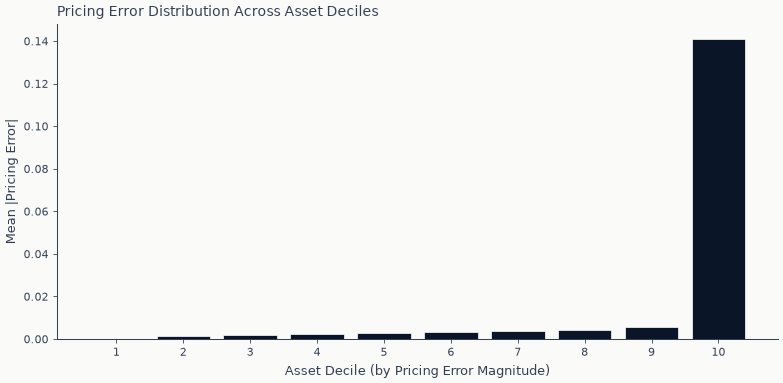

In [30]:
# Sort assets by absolute pricing error into deciles
n_assets = len(abs_pe)
sorted_idx = np.argsort(abs_pe)
decile_size = n_assets // 10
decile_errors = []
for d in range(10):
    start = d * decile_size
    end = start + decile_size if d < 9 else n_assets
    decile_errors.append(abs_pe[sorted_idx[start:end]].mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, 11), decile_errors, color=COLORS["blue"], edgecolor="white")
ax.set_xlabel("Asset Decile (by Pricing Error Magnitude)")
ax.set_ylabel("Mean |Pricing Error|")
ax.set_title("Pricing Error Distribution Across Asset Deciles")
ax.set_xticks(range(1, 11))
fig.tight_layout()
fig.show()

**Interpretation**: The pricing-error distribution reveals where the SDF struggles.
If errors concentrate in the highest decile (worst-mispriced assets), the model may
be failing on a specific market segment (often microcaps or illiquid stocks). A well-specified
SDF should have relatively uniform pricing errors across deciles, consistent with
the no-arbitrage condition $E[M \cdot R_i] = 0$ for all assets.

## 8. Training Visualization

In [31]:
history_df = pd.DataFrame(all_history)
phase1_end = NUM_EPOCHS_UNCONDITIONAL


def add_phase_boundaries(ax):
    """Add vertical lines at phase transition points."""
    for i in range(NUM_ADVERSARIAL_ROUNDS):
        p1 = phase1_end + i * (NUM_EPOCHS_INSTRUMENTS + NUM_EPOCHS_CONDITIONAL)
        p2 = p1 + NUM_EPOCHS_INSTRUMENTS
        if p1 < len(history_df):
            ax.axvline(p1, color="gray", linestyle="--", alpha=0.5)
        if p2 < len(history_df):
            ax.axvline(p2, color="gray", linestyle=":", alpha=0.5)

### Adversarial Training Dynamics

The loss and Sharpe curves reveal the three-phase training dynamics: unconditional
warmup, adversarial disruption (loss spikes), and conditional recovery.

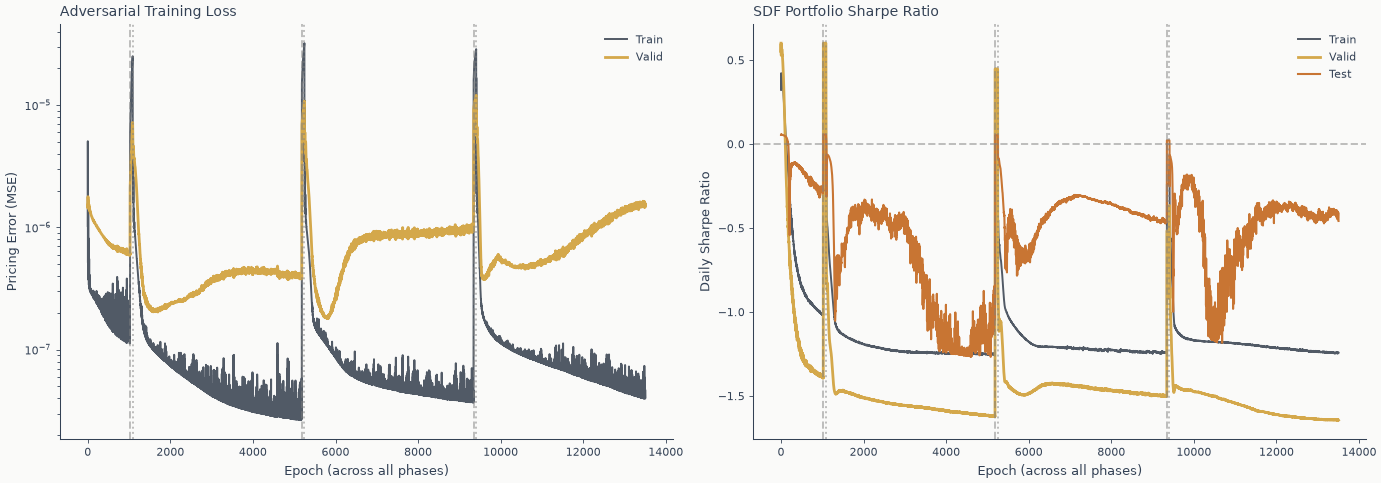

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves with phase annotations
ax1 = axes[0]
ax1.plot(history_df["loss_train"], label="Train", color=COLORS["blue"], alpha=0.7)
ax1.plot(history_df["loss_valid"], label="Valid", color=COLORS["amber"], linewidth=2)
ax1.set_xlabel("Epoch (across all phases)")
ax1.set_ylabel("Pricing Error (MSE)")
ax1.set_title("Adversarial Training Loss")
ax1.legend()
ax1.set_yscale("log")

add_phase_boundaries(ax1)

# Sharpe ratio evolution
ax2 = axes[1]
ax2.plot(history_df["sharpe_train"], label="Train", color=COLORS["blue"], alpha=0.7)
ax2.plot(history_df["sharpe_valid"], label="Valid", color=COLORS["amber"], linewidth=2)
ax2.plot(history_df["sharpe_test"], label="Test", color=COLORS["copper"], linewidth=1.5)
ax2.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax2.set_xlabel("Epoch (across all phases)")
ax2.set_ylabel("Daily Sharpe Ratio")
ax2.set_title("SDF Portfolio Sharpe Ratio")
ax2.legend()

add_phase_boundaries(ax2)

fig.tight_layout()
fig.show()

## 9. SDF Portfolio Analysis

In [33]:
# Get final SDF for test set (rolling LSTM state through train/valid first)
with torch.no_grad():
    h_sdf, c_sdf = None, None
    for split in ["train", "valid"]:
        _, (h_sdf, c_sdf) = sdf_net(
            data[split].asset_features,
            data[split].macro_features,
            data[split].mask,
            h_sdf,
            c_sdf,
        )

    test_weights, _ = sdf_net(
        data["test"].asset_features,
        data["test"].macro_features,
        data["test"].mask,
        h_sdf,
        c_sdf,
    )
    test_sdf = construct_sdf(test_weights, data["test"].returns, data["test"].mask)

sdf_np = test_sdf.cpu().numpy()
# SDF kernel construction: M_t = 1 + sum_i(w_i * r_{i,t})
# → SDF-portfolio excess return is ω·R^e = M_t - 1 (see `construct_sdf`).
# Plot the portfolio excess returns directly; clip extreme spikes for visualisation
# only (raw values feed the Sharpe statistic above).
sdf_returns = sdf_np - 1
finite_sdf_returns = sdf_returns[np.isfinite(sdf_returns)]
# Cumulative return path with per-period clipping at ±50% so a single end-of-test
# spike does not collapse the y-axis scale.
clipped = np.clip(finite_sdf_returns, -0.5, 0.5)
cumulative = np.cumprod(1 + clipped) - 1 if clipped.size else np.array([], dtype=float)

### SDF Portfolio Performance

The cumulative return and distribution of the learned SDF portfolio on the test set.

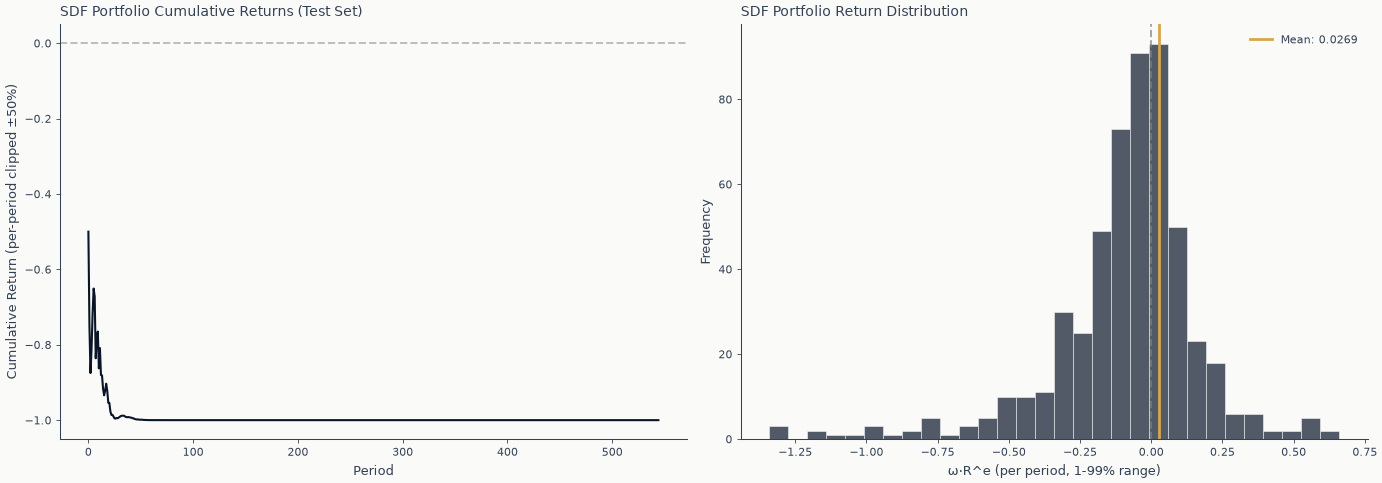

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
if cumulative.size:
    ax1.plot(cumulative, color=COLORS["blue"], linewidth=1.5)
else:
    ax1.text(0.5, 0.5, "No finite SDF returns in reduced run", ha="center", va="center")
ax1.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax1.set_xlabel("Period")
ax1.set_ylabel("Cumulative Return (per-period clipped ±50%)")
ax1.set_title("SDF Portfolio Cumulative Returns (Test Set)")


ax2 = axes[1]
if finite_sdf_returns.size:
    # Use 1st-99th percentile for the histogram range so a handful of extreme spikes
    # do not collapse the distribution into a single bin. The mean line uses the raw
    # series so the cited statistic is unaffected.
    lo, hi = np.quantile(finite_sdf_returns, [0.01, 0.99])
    ax2.hist(
        finite_sdf_returns,
        bins=30,
        range=(lo, hi),
        color=COLORS["blue"],
        alpha=0.7,
        edgecolor="white",
    )
    ax2.axvline(0, color="gray", linestyle="--", alpha=0.7)
    ax2.axvline(
        finite_sdf_returns.mean(),
        color=COLORS["amber"],
        linewidth=2,
        label=f"Mean: {finite_sdf_returns.mean():.4f}",
    )
else:
    ax2.text(0.5, 0.5, "No finite SDF returns in reduced run", ha="center", va="center")
ax2.set_xlabel("ω·R^e (per period, 1-99% range)")
ax2.set_ylabel("Frequency")
ax2.set_title("SDF Portfolio Return Distribution")
if finite_sdf_returns.size:
    ax2.legend()

fig.tight_layout()
fig.show()

**Interpretation**: The SDF portfolio's cumulative return and distribution provide
insight into the pricing kernel's behavior. A well-functioning SDF should exhibit:
- Positive mean return consistent with the Hansen-Jagannathan bound
- Return variability that reflects regime-dependent pricing
- The annualized Sharpe ratio should approach (but not exceed) the theoretical
  maximum implied by the HJ bound for this asset universe

**Caveat**: These results are in-sample for the test period (not truly out-of-sample
walk-forward). See [`08_latent_factors`](../case_studies/us_firm_characteristics/08_latent_factors.ipynb) for
walk-forward evaluation on the full CPZ dataset.

## 10. Predictive Head — Beta Network (Figure 14.11, right half)

**The framework's exception, made operational.** Sections 1-9 deliver the
trained pricing kernel: $\hat\omega_{t,i}$ (SDF weights), $\hat M_{t+1}$
(the kernel itself), Sharpe and pricing-error diagnostics. None of those
is a per-asset return forecast — ranking stocks by $\hat\omega$ is a
category mismatch (gpt-01 spec §"Important implementation cautions").

To get a per-asset prediction comparable to CAE/IPCA's $\hat\mu$, we train
a separate **beta network** on the supervised target
$y_{t,i} = R^e_{t+1,i}\,\hat F_{t+1}$, where
$\hat F_{t+1} = \hat M_{t+1} - 1 = \sum_i \hat\omega_{t,i} R^e_{t+1,i}$ is
the realised tangency factor return. Under no-arbitrage,
$b_\psi(h_t, I_{t,i})$ converges to
$\mathbb{E}_t[R^e_{t+1,i}\hat F_{t+1}] \propto \hat\beta_{t,i}$, the
loading on the tangency factor. We rank stocks by $\hat\beta_{t,i}$.

The beta network has the same architectural shape as the SDF network — its
own MacroLSTM + FFN — but it is trained on a different objective (MSE
against $y_{t,i}$) after SDF training has frozen $\hat\omega$.

### Beta Network class

In [35]:
class BetaNetwork(nn.Module):
    """Beta Network: (h_t macro state, I_{t,i} chars) → β̂_{t,i}.

    Trained on y_{t,i} = R^e_{t+1,i} · F̂_{t+1} with MSE loss. Architecture
    parallels SDFNetwork: independent MacroLSTM + FFN with one scalar output
    per valid (timestamp, asset) observation.
    """

    def __init__(
        self,
        n_asset_features: int,
        n_macro_features: int,
        state_dim: int = 4,
        hidden_dim: int = 64,
        dropout: float = 0.05,
    ):
        super().__init__()
        self.state_dim = state_dim

        self.lstm = nn.LSTM(
            input_size=n_macro_features,
            hidden_size=state_dim,
            batch_first=True,
            dropout=dropout,
        )

        self.ffn = nn.Sequential(
            nn.Linear(n_asset_features + state_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(
        self,
        asset_features: torch.Tensor,
        macro_features: torch.Tensor,
        mask: torch.Tensor,
        h0: torch.Tensor | None = None,
        c0: torch.Tensor | None = None,
    ) -> tuple[torch.Tensor, tuple[torch.Tensor, torch.Tensor]]:
        T, N, F = asset_features.shape

        if h0 is None:
            h0 = torch.zeros(1, 1, self.state_dim, device=asset_features.device)
            c0 = torch.zeros(1, 1, self.state_dim, device=asset_features.device)

        macro_seq = macro_features.unsqueeze(0)
        macro_states, (h_n, c_n) = self.lstm(macro_seq, (h0, c0))
        macro_states = macro_states.squeeze(0)

        macro_tiled = macro_states.unsqueeze(1).expand(-1, N, -1)
        asset_flat = asset_features[mask]
        macro_flat = macro_tiled[mask]

        ffn_input = torch.cat([asset_flat, macro_flat], dim=1)
        beta = self.ffn(ffn_input).squeeze(-1)

        return beta, (h_n, c_n)

### Build supervised targets — $y_{t,i} = R^e_{t+1,i}\,\hat F_{t+1} / s$

Compute $\hat F_{t+1}$ on the training window using the frozen SDF, shift
forward by one period to align with $R^e_{t+1,i}$, and broadcast to the
masked panel. Divide by $s = \mathrm{std}(\hat F)$ on the training window
so the target stays on a bounded scale across splits — the SDF weights
carry no unit-norm constraint, so raw $\hat F$ can blow up during stress
periods (e.g. the GFC inside the validation window). The β̂ output is
rank-based at evaluation, so this scale convention does not affect IC.

In [36]:
def build_beta_targets(split_name: str, prev_state, f_hat_scale: float | None = None):
    """Compute y_{t,i} = R^e_{t+1,i} · F̂_{t+1} / s, with s = std(F̂_train).

    Normalising F̂ by its training-window std keeps `y` on a bounded scale
    across splits; the SDF weights have no unit-norm constraint, so raw F̂
    can blow up during stress periods (e.g. GFC in the validation window).
    """
    sdf_net.eval()
    with torch.no_grad():
        weights, new_state = sdf_net(
            data[split_name].asset_features,
            data[split_name].macro_features,
            data[split_name].mask,
            *(prev_state if prev_state is not None else (None, None)),
        )
        sdf = construct_sdf(weights, data[split_name].returns, data[split_name].mask)
        f_hat = sdf - 1  # tangency factor return per period (= sum_i w_i * r_i)

        T_split = data[split_name].returns.shape[0]
        if T_split < 2:
            return None
        if f_hat_scale is None:
            scale = f_hat.std().clamp(min=1e-8).item()
        else:
            scale = f_hat_scale
        f_hat = f_hat / scale

        # Shift forward: y_{t,i} uses F̂_{t+1}, so align returns_{t+1} with f_hat_{t+1}
        returns_next = data[split_name].returns[1:]
        f_hat_next = f_hat[1:]
        mask_next = data[split_name].mask[1:]
        asset_features_now = data[split_name].asset_features[:-1]
        macro_features_now = data[split_name].macro_features[:-1]
        mask_now = data[split_name].mask[:-1]

        # y_{t,i} on the panel formed at decision time t with target at t+1
        # Use the intersection mask so both r_{t+1,i} and the input chars at t are valid
        joint_mask = mask_now & mask_next
        y = (returns_next * f_hat_next.unsqueeze(1)).masked_fill(~joint_mask, 0.0)

    return {
        "asset_features": asset_features_now,
        "macro_features": macro_features_now,
        "mask": joint_mask,
        "y": y,
        "returns_next": returns_next,
        "next_state": new_state,
        "f_hat_scale": scale,
    }

In [37]:
print("Building (asset, macro, y) tuples for beta-network training...")
beta_train = build_beta_targets("train", None)
beta_valid = build_beta_targets("valid", beta_train["next_state"], beta_train["f_hat_scale"])
beta_test = build_beta_targets("test", beta_valid["next_state"], beta_train["f_hat_scale"])
assert beta_train is not None and beta_valid is not None and beta_test is not None


print(
    f"  train: T={beta_train['asset_features'].shape[0]}, "
    f"valid_obs={beta_train['mask'].sum().item():,}"
)
print(
    f"  valid: T={beta_valid['asset_features'].shape[0]}, "
    f"valid_obs={beta_valid['mask'].sum().item():,}"
)
print(
    f"  test:  T={beta_test['asset_features'].shape[0]}, "
    f"valid_obs={beta_test['mask'].sum().item():,}"
)

Building (asset, macro, y) tuples for beta-network training...
  train: T=1632, valid_obs=285,546
  valid: T=543, valid_obs=101,622
  test:  T=544, valid_obs=93,985


### Train the beta network with MSE on $y_{t,i}$

In [38]:
beta_net = BetaNetwork(
    n_asset_features=N_ASSET_FEATURES,
    n_macro_features=N_MACRO_FEATURES,
    state_dim=BETA_NET_STATE_DIM,
    hidden_dim=BETA_NET_HIDDEN_DIM,
    dropout=DROPOUT,
).to(device)

beta_optimizer = optim.Adam(beta_net.parameters(), lr=BETA_NET_LR)

print(f"Beta Network parameters: {sum(p.numel() for p in beta_net.parameters()):,}")

Beta Network parameters: 5,553


In [39]:
def beta_loss(split, *, diagnostic_label: str | None = None):
    """MSE between β̂(h_t, I_{t,i}) and y_{t,i} on valid observations.

    Gates the squared-error tensor with a finiteness mask. The SDF can blow
    up during stress windows (e.g. the GFC inside the validation split),
    which propagates through ``y = R^e_{t+1} · F̂_{t+1}`` and would otherwise
    drive Valid MSE to inf at every epoch — silently disabling best-state
    selection. Dropping the non-finite positions keeps the validation loss
    informative without masking out the (typically rare) blow-up rows from
    training.
    """
    pred, _ = beta_net(
        split["asset_features"],
        split["macro_features"],
        split["mask"],
    )
    target = split["y"][split["mask"]]
    sq_err = (pred - target) ** 2
    finite = torch.isfinite(sq_err)
    if diagnostic_label is not None and not finite.all():
        n_total = finite.numel()
        n_bad = int((~finite).sum().item())
        pred_bad = int((~torch.isfinite(pred)).sum().item())
        target_bad = int((~torch.isfinite(target)).sum().item())
        print(
            f"  [beta_loss diagnostic | {diagnostic_label}] "
            f"non-finite sq_err: {n_bad:,}/{n_total:,} "
            f"(pred non-finite: {pred_bad:,}, target non-finite: {target_bad:,})"
        )
    if finite.all():
        return sq_err.mean()
    return sq_err[finite].mean()

In [40]:
beta_history = []
best_valid = float("inf")
best_state = None
start_time = time()

for epoch in range(BETA_NET_EPOCHS):
    beta_net.train()
    train_diag = "epoch1/train" if epoch == 0 else None
    loss = beta_loss(beta_train, diagnostic_label=train_diag)
    beta_optimizer.zero_grad()
    loss.backward()
    beta_optimizer.step()

    beta_net.eval()
    with torch.no_grad():
        train_l = loss.item()
        valid_diag = "epoch1/valid" if epoch == 0 else None
        valid_l = beta_loss(beta_valid, diagnostic_label=valid_diag).item()

    beta_history.append({"epoch": epoch + 1, "train_loss": train_l, "valid_loss": valid_l})

    if valid_l < best_valid:
        best_valid = valid_l
        best_state = {k: v.clone() for k, v in beta_net.state_dict().items()}

    if (epoch + 1) % max(1, BETA_NET_EPOCHS // 10) == 0:
        elapsed = time() - start_time
        print(
            f"  Epoch {epoch + 1:4d}/{BETA_NET_EPOCHS} | "
            f"Train MSE: {train_l:.6e} | Valid MSE: {valid_l:.6e} | "
            f"Time: {elapsed:.1f}s"
        )

if best_state is not None:
    beta_net.load_state_dict(best_state)

print(f"\nBest validation MSE: {best_valid:.6e}")

  [beta_loss diagnostic | epoch1/valid] non-finite sq_err: 2/101,622 (pred non-finite: 0, target non-finite: 0)


  Epoch   25/256 | Train MSE: 9.103958e-03 | Valid MSE: 6.996287e-04 | Time: 0.2s


  Epoch   50/256 | Train MSE: 8.597935e-03 | Valid MSE: 5.755128e-04 | Time: 0.4s


  Epoch   75/256 | Train MSE: 8.442370e-03 | Valid MSE: 5.140689e-04 | Time: 0.6s


  Epoch  100/256 | Train MSE: 8.252124e-03 | Valid MSE: 4.951906e-04 | Time: 0.9s


  Epoch  125/256 | Train MSE: 8.050784e-03 | Valid MSE: 5.251467e-04 | Time: 1.1s
  Epoch  150/256 | Train MSE: 7.673089e-03 | Valid MSE: 5.376800e-04 | Time: 1.3s


  Epoch  175/256 | Train MSE: 7.261876e-03 | Valid MSE: 6.016794e-04 | Time: 1.5s


  Epoch  200/256 | Train MSE: 7.099043e-03 | Valid MSE: 6.727850e-04 | Time: 1.7s


  Epoch  225/256 | Train MSE: 7.018563e-03 | Valid MSE: 6.890049e-04 | Time: 2.0s


  Epoch  250/256 | Train MSE: 6.896384e-03 | Valid MSE: 6.617255e-04 | Time: 2.2s

Best validation MSE: 4.917256e-04


### Evaluate β̂ vs forward returns on the test set

Compute per-asset $\hat\beta_{t,i}$ and score it against $R^e_{t+1,i}$ —
this is the per-asset prediction quality directly comparable to CAE / IPCA
IC tables. The Sharpe / pricing-error metrics in §7-9 are SDF-portfolio
diagnostics, distinct from this signal-quality measurement.

In [41]:
beta_net.eval()
with torch.no_grad():
    beta_pred, _ = beta_net(
        beta_test["asset_features"],
        beta_test["macro_features"],
        beta_test["mask"],
    )
    beta_pred_np = beta_pred.cpu().numpy()
    forward_returns_np = beta_test["returns_next"][beta_test["mask"]].cpu().numpy()

    # Map every valid obs to its (period, symbol) index pair.
    T_test_eff, N_test_eff = beta_test["mask"].shape
    period_grid = (
        torch.arange(T_test_eff, device=device)
        .unsqueeze(1)
        .expand(-1, N_test_eff)[beta_test["mask"]]
    )
    symbol_grid = (
        torch.arange(N_test_eff, device=device)
        .unsqueeze(0)
        .expand(T_test_eff, -1)[beta_test["mask"]]
    )
    period_idx_np = period_grid.cpu().numpy()
    symbol_idx_np = symbol_grid.cpu().numpy()

In [42]:
def _ic_long_form(predictions, actuals, period_idx, symbol_idx):
    """Build a (date, symbol, y_pred, y_true) frame keeping only finite rows."""
    mask = np.isfinite(predictions) & np.isfinite(actuals)
    return pl.DataFrame(
        {
            "date": np.asarray(period_idx)[mask],
            "symbol": np.asarray(symbol_idx)[mask],
            "y_pred": predictions[mask],
            "y_true": actuals[mask],
        }
    )


def per_period_ic(predictions, actuals, period_idx, symbol_idx, min_n=20):
    """Per-date Spearman IC series via the diagnostic library."""
    df = _ic_long_form(predictions, actuals, period_idx, symbol_idx)
    if df.height == 0:
        return np.array([])
    series = cross_sectional_ic_series(
        predictions=df,
        returns=df,
        pred_col="y_pred",
        ret_col="y_true",
        date_col="date",
        entity_col="symbol",
        method="spearman",
        min_obs=min_n,
    )
    return series.drop_nulls("ic")["ic"].to_numpy()

In [43]:
df_long = _ic_long_form(beta_pred_np, forward_returns_np, period_idx_np, symbol_idx_np)
summary = cross_sectional_ic(
    predictions=df_long,
    returns=df_long,
    pred_col="y_pred",
    ret_col="y_true",
    date_col="date",
    entity_col="symbol",
    method="spearman",
    min_obs=20,
)
ic_series = per_period_ic(beta_pred_np, forward_returns_np, period_idx_np, symbol_idx_np)
ic_mean = float(summary["ic_mean"])
ic_std = float(summary["ic_std"])
ic_ir = float(summary["ic_ir"])

prediction_summary = pd.DataFrame(
    {
        "Metric": [
            "Mean per-date IC (β̂ vs r^e_{t+1})",
            "Per-date IC std",
            "IC IR (mean / std, non-annualised)",
            "t-stat",
            "p-value (H0: IC=0)",
            "N test periods scored",
            "N test obs",
        ],
        "Value": [
            f"{ic_mean:.4f}",
            f"{ic_std:.4f}",
            f"{ic_ir:.4f}",
            f"{summary['ic_t']:.2f}",
            f"{summary['p_value']:.3f}",
            f"{int(summary['n_periods'])}",
            f"{len(beta_pred_np):,}",
        ],
    }
).set_index("Metric")
prediction_summary

,Value
Metric,
Mean per-date IC (β̂ vs r^e_{t+1}),0.0021
Per-date IC std,0.1689
"IC IR (mean / std, non-annualised)",0.0124
t-stat,0.29
p-value (H0: IC=0),0.773
N test periods scored,544
N test obs,"93,985"


### Cache β-Network Predictions

Save the β-network's long-form prediction frame so re-running the
downstream interpretation cells doesn't retrain the SDF or β-net. Cache
key includes the universe size, training schedule, β-network hyperparams,
and the date window; see `utils/predictions_cache.py` for the contract.

In [44]:
from utils.predictions_cache import predictions_cache_key, save_predictions

predictions_spec = {
    "notebook": "sdf",
    "data": {
        "source": "us_equities",
        "n_stocks": N_STOCKS,
        "start_date": START_DATE,
        "end_date": END_DATE,
        "n_macro_cols": N_MACRO_COLS,
    },
    "model": {
        "name": "sdf_beta_net",
        "epochs_unconditional": NUM_EPOCHS_UNCONDITIONAL,
        "epochs_instruments": NUM_EPOCHS_INSTRUMENTS,
        "epochs_conditional": NUM_EPOCHS_CONDITIONAL,
        "adversarial_rounds": NUM_ADVERSARIAL_ROUNDS,
        "beta_net_epochs": BETA_NET_EPOCHS,
        "beta_net_hidden_dim": BETA_NET_HIDDEN_DIM,
        "beta_net_state_dim": BETA_NET_STATE_DIM,
        "beta_net_lr": BETA_NET_LR,
    },
}

cache_frame = df_long.with_columns(pl.lit("beta_net").alias("forecaster"))
save_predictions(chapter=14, notebook_id="sdf", spec=predictions_spec, frame=cache_frame)
print(f"Cached {len(cache_frame):,} rows under key {predictions_cache_key(predictions_spec)}")

Cached 93,985 rows under key e5e8fae4d0ed


**Reading the table**: the β-network's per-date Spearman IC against next-day
excess returns is $+0.002$ on average (IR $+0.012$, $t=0.29$, $p=0.773$ over
544 test periods, $\approx 94k$ stock-day observations) — indistinguishable
from zero. The SDF's β loadings carry no reliable cross-sectional signal on
next-day returns in this specification; whatever value the SDF has lives in
the time-series tangency weights $\hat\omega$ rather than in the
cross-sectional loadings, on a US-equities top-200 panel of 1990–2018 daily
data. The SDF portfolio's annualised Sharpe is itself weak and unstable
across splits (test $0.15$, but train $-2.44$ and valid $-5.81$ in §7), so
this is an architecture/method demonstration rather than a deployable signal.
In short, the β-IC is not statistically significant, so SDF
β-loadings should not be relied on in isolation — compare against the
case-study walk-forward run rather than this single contemporaneous fit.

### Beta-network training and IC distribution

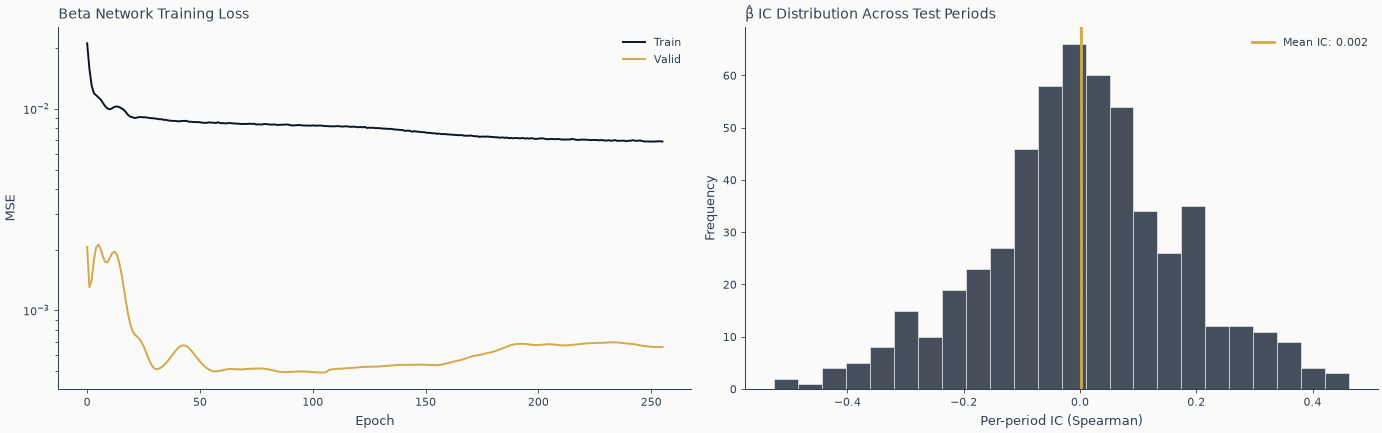

In [45]:
beta_history_df = pd.DataFrame(beta_history)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

ax1 = axes[0]
ax1.plot(beta_history_df["train_loss"], label="Train", color=COLORS["blue"], linewidth=1.4)
ax1.plot(beta_history_df["valid_loss"], label="Valid", color=COLORS["amber"], linewidth=1.4)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("MSE")
ax1.set_yscale("log")
ax1.set_title("Beta Network Training Loss")
ax1.legend()

ax2 = axes[1]
if len(ic_series):
    ax2.hist(ic_series, bins=24, color=COLORS["blue"], alpha=0.75, edgecolor="white")
    ax2.axvline(0, color="gray", linestyle=":", linewidth=1)
    ax2.axvline(ic_mean, color=COLORS["amber"], linewidth=2, label=f"Mean IC: {ic_mean:.3f}")
    ax2.legend()
else:
    ax2.text(0.5, 0.5, "Insufficient periods to score", ha="center", va="center")
ax2.set_xlabel("Per-period IC (Spearman)")
ax2.set_ylabel("Frequency")
ax2.set_title("β̂ IC Distribution Across Test Periods")

fig.tight_layout()
fig.show()

**Reading the curves**: training and validation MSE should descend
together. Diverging validation = overfit; flat training = LR too low or
the task carries little signal. The IC histogram tells the same story for
the per-asset prediction objective.

## 11. Key Takeaways

1. **SDF is the framework's exception**: PCA/IPCA/CAE expose a swappable
   Stage 2 forecaster on top of $F$; the SDF folds forecasting into the
   conditional moment objective. The two-step decomposition is descriptive,
   not prescriptive — when an architecture's economic content lives in the
   joint optimisation, you keep it joint.
2. **Adversarial training finds robust SDFs**: the minimax structure
   disciplines the pricing kernel against the hardest test portfolios, not
   just the average pricing error. This is what distinguishes CPZ 2024
   from reconstruction-error objectives like CAE.
3. **MacroLSTM captures regime dependence**: the learned macro state
   conditions the SDF (and the beta network) on economic regime without
   manual specification. Both networks share architectural shape but learn
   different objectives.
4. **Two distinct evaluations**: SDF Sharpe + pricing-error decile spread
   measure pricing-kernel quality (§7-9); β̂ IC vs forward returns
   measures per-asset prediction quality (§10). They answer different
   questions and need not move together.
5. **Never rank stocks by $\hat\omega$**: the SDF weights are portfolio
   weights, not expected-return signals. The beta network is what turns
   SDF training into a forecasting protocol comparable to the rest of the
   chapter.
6. **Daily Sharpe annualises with $\sqrt{252}$**: a common pitfall — using
   $\sqrt{12}$ on daily data inflates Sharpe by ~4.6×. Match the
   $\sqrt{N}$ rule to the data frequency.

**Next**: [`08_supervised_autoencoder`](08_supervised_autoencoder.ipynb) —
supervised end-to-end multi-task learning, also outside the Stage 2 / Stage 3
split (no separable forecaster — the autoencoder fits forward returns
directly). [`08_latent_factors`](../case_studies/us_firm_characteristics/08_latent_factors.ipynb)
applies all five LF estimators (PCA, IPCA, CAE, SDF with beta network, SAE)
at full scale with walk-forward CV.